In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("sales_data.csv")
print(data.isnull().sum())

order_id            0
date                0
customer_id         0
customer_name       0
age                 0
gender              0
region              0
category            0
product             0
quantity            0
unit_price          0
discount_pct        0
payment_method      0
order_status        0
rating            995
dtype: int64


In [3]:
print(data.duplicated().any())

False


In [4]:
data.fillna(0, inplace = True)

,order_id,date,customer_id,customer_name,age,gender,region,category,product,quantity,unit_price,discount_pct,payment_method,order_status,rating
0,ORD00001,2023-11-24,CUST2419,Rahul,45,M,North,Books,Comics,4,1154.89,0,Credit Card,Delivered,3.2
1,ORD00002,2023-03-06,CUST0027,Suresh,28,M,West,Sports,Dumbbells,1,2828.16,20,UPI,Pending,3.4
2,ORD00003,2023-01-03,CUST0178,Suresh,64,M,West,Toys,RC Car,2,509.09,0,Debit Card,Delivered,3.4
3,ORD00004,2023-08-15,CUST2709,Anita,32,F,East,Sports,Badminton Set,10,4432.99,10,Credit Card,Returned,1.3
4,ORD00005,2022-08-03,CUST2800,Nikhil,59,M,North,Food,Dal 2kg,6,855.14,10,Debit Card,Returned,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD09996,2022-01-16,CUST0774,Rahul,39,M,East,Books,Self-Help,7,4729.64,20,Debit Card,Returned,1.4
9996,ORD09997,2022-03-09,CUST0277,Priya,38,F,West,Food,Rice 5kg,2,1160.95,5,Net Banking,Returned,2.8
9997,ORD09998,2023-08-12,CUST2157,Arjun,45,M,North,Clothing,T-Shirt,1,3672.83,10,UPI,Pending,3.1
9998,ORD09999,2022-03-28,CUST0987,Arjun,39,M,Central,Electronics,Headphones,8,4676.49,20,Debit Card,Delivered,2.2


In [5]:
print(data["rating"].isnull().sum())

0


In [6]:
data["year"] = pd.to_datetime(data["date"]).dt.year
data["month"] = pd.to_datetime(data["date"]).dt.month
data["day"] = pd.to_datetime(data["date"]).dt.day
data["revenue"] = data["quantity"] * data["unit_price"]
print(data.head(1).to_string())

   order_id        date customer_id customer_name  age gender region category product  quantity  unit_price  discount_pct payment_method order_status  rating  year  month  day  revenue
0  ORD00001  2023-11-24    CUST2419         Rahul   45      M  North    Books  Comics         4     1154.89             0    Credit Card    Delivered     3.2  2023     11   24  4619.56


In [7]:
print(data.columns)

Index(['order_id', 'date', 'customer_id', 'customer_name', 'age', 'gender',
       'region', 'category', 'product', 'quantity', 'unit_price',
       'discount_pct', 'payment_method', 'order_status', 'rating', 'year',
       'month', 'day', 'revenue'],
      dtype='str')


In [8]:
print(data.head(5).to_string())


   order_id        date customer_id customer_name  age gender region category        product  quantity  unit_price  discount_pct payment_method order_status  rating  year  month  day   revenue
0  ORD00001  2023-11-24    CUST2419         Rahul   45      M  North    Books         Comics         4     1154.89             0    Credit Card    Delivered     3.2  2023     11   24   4619.56
1  ORD00002  2023-03-06    CUST0027        Suresh   28      M   West   Sports      Dumbbells         1     2828.16            20            UPI      Pending     3.4  2023      3    6   2828.16
2  ORD00003  2023-01-03    CUST0178        Suresh   64      M   West     Toys         RC Car         2      509.09             0     Debit Card    Delivered     3.4  2023      1    3   1018.18
3  ORD00004  2023-08-15    CUST2709         Anita   32      F   East   Sports  Badminton Set        10     4432.99            10    Credit Card     Returned     1.3  2023      8   15  44329.90
4  ORD00005  2022-08-03    CUST2800

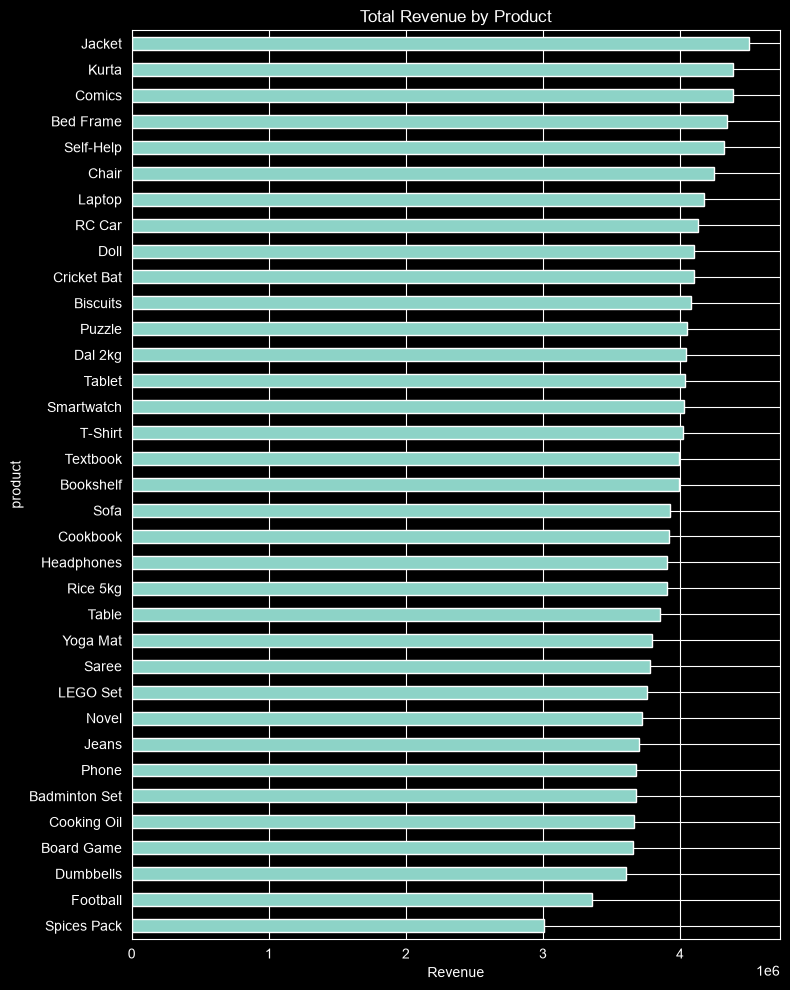

In [9]:
product_revenue = data.groupby("product")["revenue"].sum().sort_values(ascending = False)
product_revenue.sort_values().plot(kind="barh", figsize=(8, 10))
plt.title("Total Revenue by Product")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

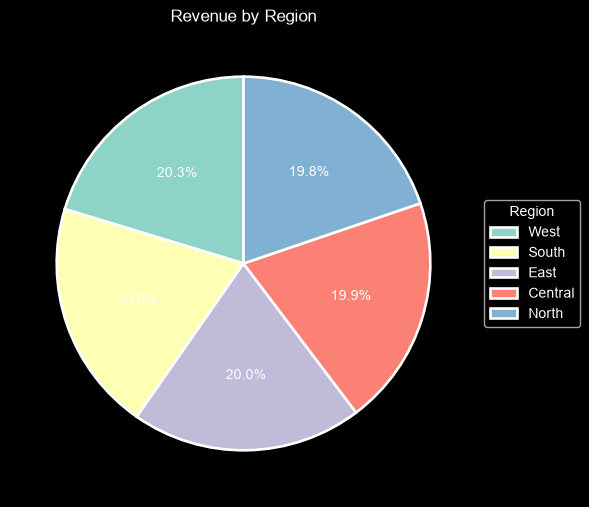

In [10]:
regional_revenue = data.groupby(["region"])["revenue"].sum().sort_values(ascending = False)
fig, ax = plt.subplots(figsize=(6, 8))
wedges, texts, autotexts = ax.pie(
    regional_revenue, autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.9}
)
ax.legend(wedges, regional_revenue.index, title="Region", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("Revenue by Region")
plt.tight_layout()
plt.show()

In [11]:
gender_product = data.groupby(["product", "gender"]).size().unstack()
print(gender_product)

gender           F    M
product                
Badminton Set  119  157
Bed Frame      150  154
Biscuits       151  146
Board Game     139  150
Bookshelf      140  144
Chair          156  134
Comics         138  157
Cookbook       154  152
Cooking Oil    137  142
Cricket Bat    135  142
Dal 2kg        134  152
Doll           122  152
Dumbbells      126  137
Football       132  129
Headphones     153  148
Jacket         125  170
Jeans          133  124
Kurta          153  149
LEGO Set       159  123
Laptop         140  157
Novel          131  151
Phone          147  140
Puzzle         141  158
RC Car         124  155
Rice 5kg       137  148
Saree          146  116
Self-Help      138  170
Smartwatch     143  154
Sofa           135  146
Spices Pack    116  129
T-Shirt        155  146
Table          142  149
Tablet         146  155
Textbook       122  155
Yoga Mat       158  132


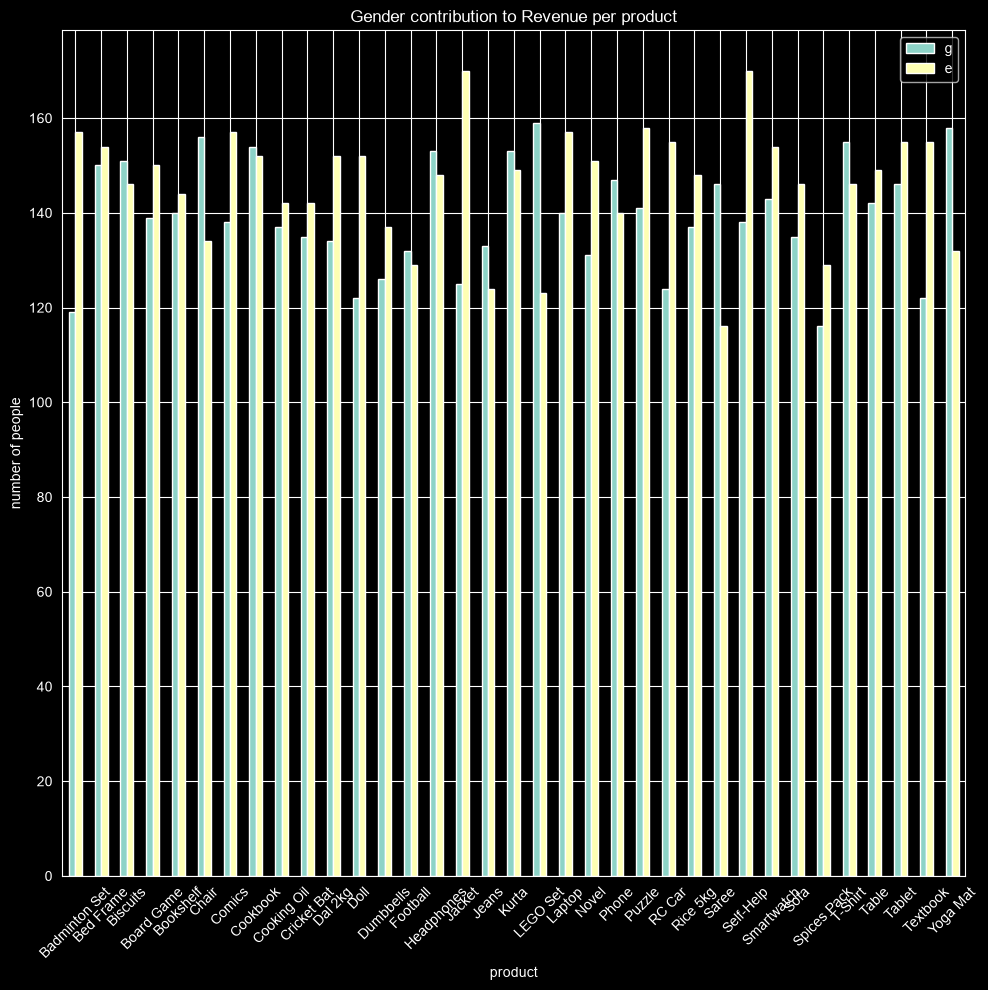

In [12]:
gender_product.plot( kind = "bar" , figsize = (10,10))
plt.xlabel("product")
plt.ylabel("number of people")
plt.title("Gender contribution to Revenue per product")
plt.xticks(rotation=45)
plt.legend("gender")
plt.tight_layout()
plt.show()

In [13]:
data["revenue"] = data["quantity"] * data["unit_price"]
data["discount %"] = data["discount"]

KeyError: 'discount'

In [ ]:
data["discount %"] = data["discount_pct"] / 100
print(data.head())

In [ ]:
data.drop(columns = ["discount_pct"])

In [ ]:
data["discounted_price"] = data["unit_price"] * data["discount %"]
print(data.head())

In [ ]:
#data.drop(columns = ["order_id", "date","customer_id","customer_name"], inplace = True)
correlated_data = data[["age","quantity","unit_price","discount %","rating","revenue"]].corr()
print(correlated_data)

In [ ]:
data.describe() #

In [15]:
data.query("year== 2023" )

,order_id,date,customer_id,customer_name,age,gender,region,category,product,quantity,unit_price,discount_pct,payment_method,order_status,rating,year,month,day,revenue
0,ORD00001,2023-11-24,CUST2419,Rahul,45,M,North,Books,Comics,4,1154.89,0,Credit Card,Delivered,3.2,2023,11,24,4619.56
1,ORD00002,2023-03-06,CUST0027,Suresh,28,M,West,Sports,Dumbbells,1,2828.16,20,UPI,Pending,3.4,2023,3,6,2828.16
2,ORD00003,2023-01-03,CUST0178,Suresh,64,M,West,Toys,RC Car,2,509.09,0,Debit Card,Delivered,3.4,2023,1,3,1018.18
3,ORD00004,2023-08-15,CUST2709,Anita,32,F,East,Sports,Badminton Set,10,4432.99,10,Credit Card,Returned,1.3,2023,8,15,44329.90
6,ORD00007,2023-02-10,CUST0586,Anita,34,F,South,Clothing,Kurta,6,1102.50,15,Cash,Pending,3.6,2023,2,10,6615.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,ORD09990,2023-07-23,CUST1320,Ravi,39,M,Central,Books,Self-Help,8,1074.38,5,Credit Card,Pending,4.5,2023,7,23,8595.04
9990,ORD09991,2023-10-16,CUST1245,Rohan,34,M,East,Clothing,Jacket,2,3627.79,15,UPI,Delivered,1.6,2023,10,16,7255.58
9991,ORD09992,2023-01-19,CUST0585,Suresh,45,M,West,Food,Biscuits,9,2213.09,0,Net Banking,Returned,0.0,2023,1,19,19917.81
9993,ORD09994,2023-03-21,CUST0745,Suresh,29,M,North,Books,Novel,2,3988.24,5,Net Banking,Returned,0.0,2023,3,21,7976.48


In [ ]:
data.sample( n = 100)